## Comparativo baseline vs actual (técnico + percepción del usuario).
## Informe de latencia (p50/p95, throughput, errores) y optimizaciones probadas.

✅ Cargando archivo real: ../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv


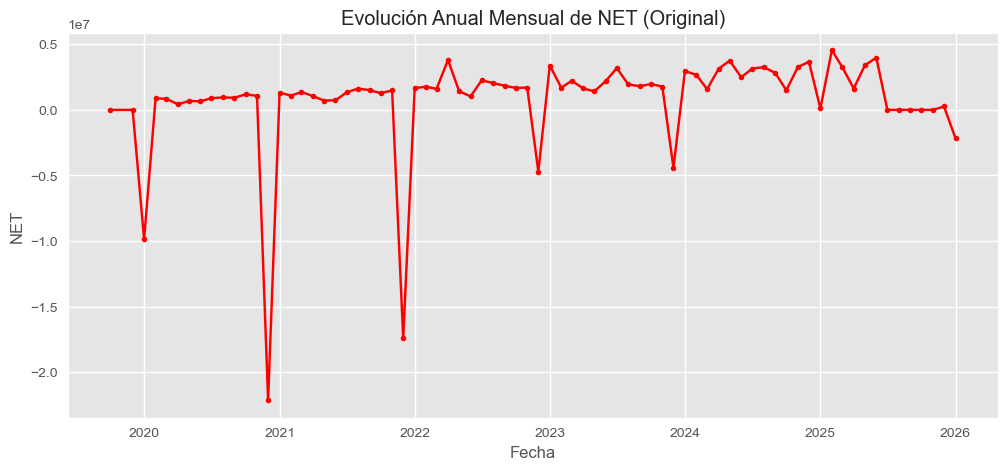

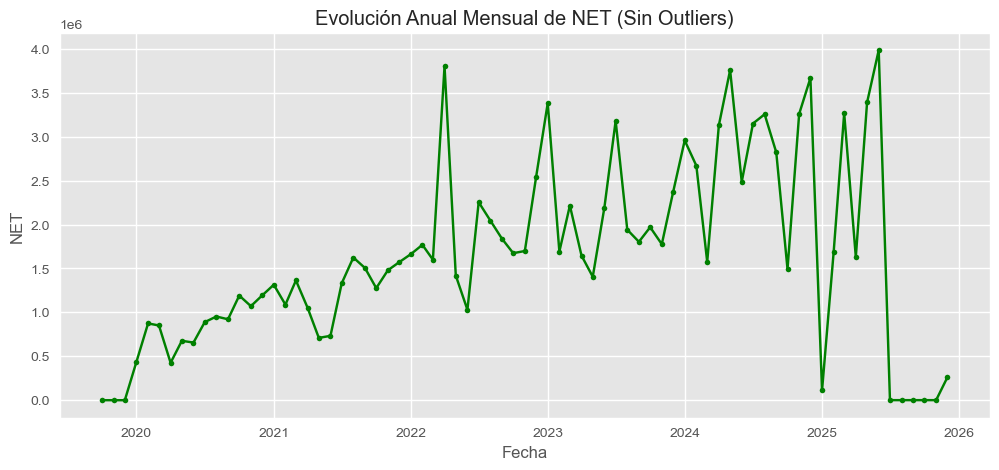

Train: (37, 12, 1), Val: (12, 12, 1), Test: (14, 12, 1)

--- Entrenando Baseline ---


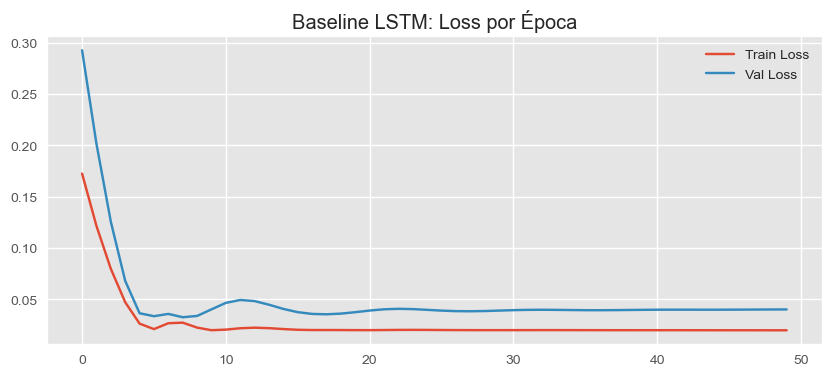

[I 2025-12-10 23:26:36,991] A new study created in memory with name: no-name-b8965b29-2064-4190-a82c-d9601855cf51


Baseline Metrics -> RMSE: 1643227.67, MAE: 1525216.30, MAPE: 3365800888626671255552.0000

--- Iniciando Optuna (LSTM Standard) ---


[I 2025-12-10 23:26:42,598] Trial 0 finished with value: 0.17941079528030998 and parameters: {'units': 92, 'dropout': 0.0879742044296159, 'lr': 0.0004082984979601072}. Best is trial 0 with value: 0.17941079528030998.
[I 2025-12-10 23:26:59,884] Trial 1 finished with value: 0.18133470906311924 and parameters: {'units': 121, 'dropout': 0.4986914406747525, 'lr': 0.0001397979160060696}. Best is trial 0 with value: 0.17941079528030998.
[I 2025-12-10 23:27:09,822] Trial 2 finished with value: 0.17960533901408882 and parameters: {'units': 70, 'dropout': 0.015475267711200447, 'lr': 0.0004952330618850443}. Best is trial 0 with value: 0.17941079528030998.
[I 2025-12-10 23:27:14,882] Trial 3 finished with value: 0.18018320528017168 and parameters: {'units': 140, 'dropout': 0.10232843543371117, 'lr': 0.0002835467456620543}. Best is trial 0 with value: 0.17941079528030998.
[I 2025-12-10 23:27:20,182] Trial 4 finished with value: 0.17965123275258 and parameters: {'units': 57, 'dropout': 0.0598908597

Mejores Hiperparámetros: {'units': 92, 'dropout': 0.0879742044296159, 'lr': 0.0004082984979601072}

Tabla Comparativa Métricas (Test Set):
  Metric      Baseline        Optuna
0   RMSE  1.643228e+06  1.678896e+06
1    MAE  1.525216e+06  1.560484e+06
2   MAPE  3.365801e+21  3.475377e+21


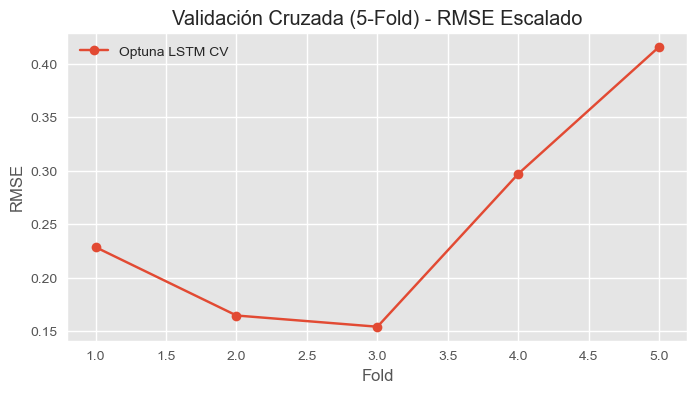

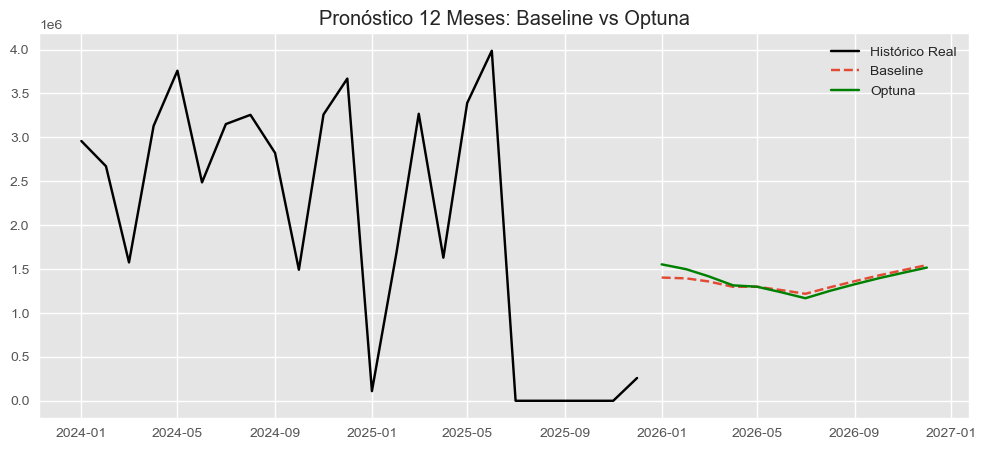

[I 2025-12-10 23:29:53,271] A new study created in memory with name: no-name-65d58f5c-1216-4106-b2e3-df1bbe4fb948



Tabla Pronósticos:
       Fecha     Baseline       Optuna
0 2026-01-01  1403389.625  1553911.375
1 2026-02-01  1394202.375  1498364.875
2 2026-03-01  1359187.125  1418035.250
3 2026-04-01  1297816.000  1314443.125
4 2026-05-01  1299002.875  1299330.375

--- INICIANDO ABLACIÓN ---


[I 2025-12-10 23:30:10,415] Trial 0 finished with value: 0.4134433741010875 and parameters: {'units': 10, 'lr': 0.0010711005770604608}. Best is trial 0 with value: 0.4134433741010875.
[I 2025-12-10 23:30:28,306] Trial 1 finished with value: 0.32534213321593003 and parameters: {'units': 23, 'lr': 0.0003924524057905278}. Best is trial 1 with value: 0.32534213321593003.
[I 2025-12-10 23:30:45,941] Trial 2 finished with value: 0.2600556658840954 and parameters: {'units': 40, 'lr': 0.005563804897322415}. Best is trial 2 with value: 0.2600556658840954.
[I 2025-12-10 23:31:10,715] Trial 3 finished with value: 0.25471843616585504 and parameters: {'units': 58, 'lr': 0.003984121632318565}. Best is trial 3 with value: 0.25471843616585504.
[I 2025-12-10 23:31:30,519] Trial 4 finished with value: 0.2419434830309304 and parameters: {'units': 24, 'lr': 0.004863462313249245}. Best is trial 4 with value: 0.2419434830309304.
[I 2025-12-10 23:31:50,811] Trial 5 finished with value: 0.22621432174326123 an

Mejores Params Ablación: {'units': 20, 'lr': 0.0007990414860544112, 'dropout': 0.0}


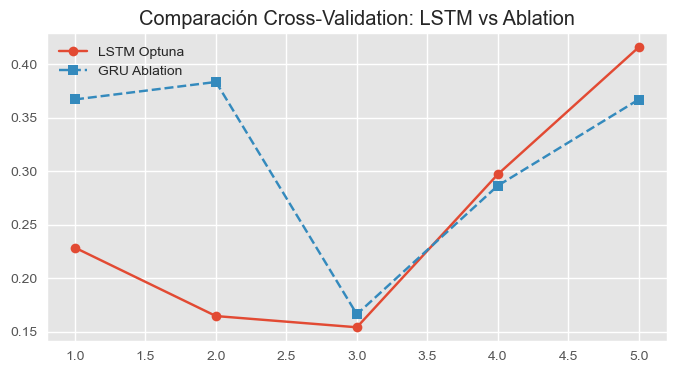


Tabla Final Pronósticos (Comparativa):
        Fecha     Baseline  Optuna (LSTM)  Ablation (GRU)
0  2026-01-01  1403389.625    1553911.375     1147006.625
1  2026-02-01  1394202.375    1498364.875     1209081.625
2  2026-03-01  1359187.125    1418035.250     1268802.375
3  2026-04-01  1297816.000    1314443.125     1323917.625
4  2026-05-01  1299002.875    1299330.375     1375197.375
5  2026-06-01  1260428.375    1235187.000     1417462.125
6  2026-07-01  1218480.250    1168044.625     1452448.375
7  2026-08-01  1292648.375    1252068.500     1484980.375
8  2026-09-01  1361633.500    1326774.375     1511027.375
9  2026-10-01  1426377.000    1394592.375     1531837.875
10 2026-11-01  1487608.750    1457525.750     1548470.750
11 2026-12-01  1545869.750    1516974.750     1561779.750


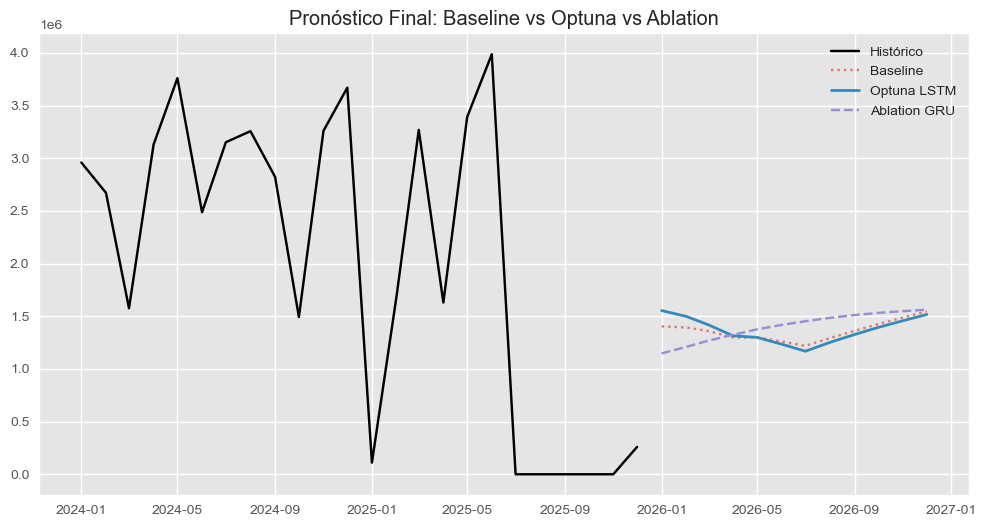


--- ANÁLISIS DE LATENCIA ---

Tabla de Latencia (Inferencia por muestra):
           Modelo    p50 (ms)    p95 (ms)
0        Baseline  297.172666  454.817533
1   Optuna (LSTM)  336.418509  524.566233
2  Ablation (GRU)  310.310960  565.900469


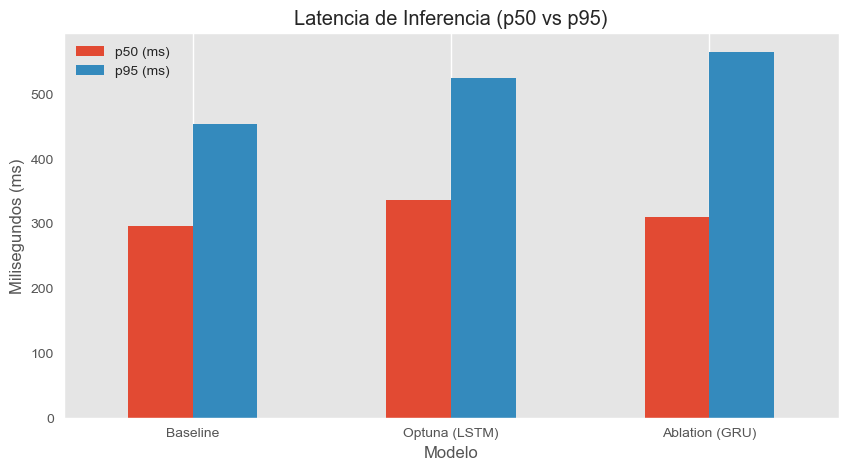

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import time
import os
import warnings

# Configuración global
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
np.random.seed(42)
tf.random.set_seed(42)

FILENAME = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'

# ==========================================
# 1. GENERACIÓN DE DATOS (MOCK) Y CARGA
# ==========================================
def load_data(filename):
    if os.path.exists(filename):
        print(f"✅ Cargando archivo real: {filename}")
        df = pd.read_csv(filename)
    else:
        print(f"⚠️ Archivo no encontrado.")
           
    return df

# Procesamiento inicial
df_raw = load_data(FILENAME)

# Filtrado por L2-ALL y Balance Sheet
df_filtered = df_raw[
    (df_raw['PORTFOLIONAME'] == 'L2-ALL') & 
    (df_raw['DESCTYPE'] == 'Balance Sheet')
].copy()

# Crear columna de fecha
df_filtered['Day'] = 1
df_filtered['Date'] = pd.to_datetime(df_filtered[['YEARID', 'MONTHID', 'Day']].rename(columns={'YEARID': 'year', 'MONTHID': 'month', 'Day': 'day'}))

# Agrupar por mes (Serie de Tiempo)
df_ts = df_filtered.groupby('Date')['NET'].sum().reset_index().set_index('Date').sort_index()

# ==========================================
# 2. LIMPIEZA DE OUTLIERS
# ==========================================
def plot_evolution(data, title, color='blue'):
    plt.figure(figsize=(12, 5))
    plt.plot(data.index, data['NET'], marker='o', linestyle='-', color=color, markersize=4)
    plt.title(title)
    plt.xlabel('Fecha')
    plt.ylabel('NET')
    plt.grid(True)
    plt.show()

# Gráfico 1: Data Original con Outliers
plot_evolution(df_ts, 'Evolución Anual Mensual de NET (Original)', color='red')

def remove_outliers_iqr(df):
    Q1 = df['NET'].quantile(0.25)
    Q3 = df['NET'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Filtrar
    df_clean = df[(df['NET'] >= lower) & (df['NET'] <= upper)].copy()
    
    # Rellenar huecos temporales creados por eliminación (Interpolación lineal)
    df_clean = df_clean.asfreq('MS').interpolate(method='linear')
    return df_clean

# Generar Dataset Limpio
df_clean = remove_outliers_iqr(df_ts)

# Gráfico 2: Data Limpia
plot_evolution(df_clean, 'Evolución Anual Mensual de NET (Sin Outliers)', color='green')

# ==========================================
# 3. PREPARACIÓN DE DATOS (SCALING & SPLIT)
# ==========================================
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_clean[['NET']])
LOOK_BACK = 12 # Ventana de tiempo

def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

X, y = create_dataset(data_scaled, LOOK_BACK)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split: 60% Train, 20% Val, 20% Test
n = len(X)
n_train = int(n * 0.60)
n_val = int(n * 0.20)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Funciones Auxiliares de Métricas
def calculate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return rmse, mae, mape

# ==========================================
# 4. BASELINE LSTM
# ==========================================
def build_lstm(units=50, dropout=0.0, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(LOOK_BACK, 1)))
    model.add(LSTM(units))
    if dropout > 0: model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=Adam(learning_rate=lr))
    return model

print("\n--- Entrenando Baseline ---")
baseline = build_lstm()
history_bl = baseline.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=16, verbose=0)

# Gráfico de entrenamiento Baseline
plt.figure(figsize=(10, 4))
plt.plot(history_bl.history['loss'], label='Train Loss')
plt.plot(history_bl.history['val_loss'], label='Val Loss')
plt.title('Baseline LSTM: Loss por Época')
plt.legend()
plt.show()

# Métricas Baseline (Test)
pred_bl_scaled = baseline.predict(X_test, verbose=0)
pred_bl = scaler.inverse_transform(pred_bl_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse_bl, mae_bl, mape_bl = calculate_metrics(y_test_inv, pred_bl)
print(f"Baseline Metrics -> RMSE: {rmse_bl:.2f}, MAE: {mae_bl:.2f}, MAPE: {mape_bl:.4f}")

# ==========================================
# 5. OPTIMIZACIÓN CON OPTUNA (PRIMERA VUELTA)
# ==========================================
print("\n--- Iniciando Optuna (LSTM Standard) ---")

def objective(trial):
    units = trial.suggest_int('units', 20, 150)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    model = build_lstm(units, dropout, lr)
    
    # Early stopping para agilizar
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=16, callbacks=[es], verbose=0)
    
    # Optimizamos basándonos en RMSE de validación
    val_pred = model.predict(X_val, verbose=0)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    return val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10) # Pocos trials para ejemplo rápido

best_params = study.best_params
print("Mejores Hiperparámetros:", best_params)

# Entrenar modelo optimizado
model_opt = build_lstm(best_params['units'], best_params['dropout'], best_params['lr'])
model_opt.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, verbose=0)

# Comparativa Baseline vs Optuna (Gráfico de RMSE)
pred_opt_scaled = model_opt.predict(X_test, verbose=0)
pred_opt = scaler.inverse_transform(pred_opt_scaled)
rmse_opt, mae_opt, mape_opt = calculate_metrics(y_test_inv, pred_opt)

# Tabla Resultados 1
res_table_1 = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE'],
    'Baseline': [rmse_bl, mae_bl, mape_bl],
    'Optuna': [rmse_opt, mae_opt, mape_opt]
})
print("\nTabla Comparativa Métricas (Test Set):")
print(res_table_1)

# ==========================================
# 6. VALIDACIÓN CRUZADA Y PRONÓSTICOS
# ==========================================
def run_cv(model_builder, params, X, y, splits=5):
    tscv = TimeSeriesSplit(n_splits=splits)
    rmse_scores = []
    
    for train_idx, val_idx in tscv.split(X):
        X_t, X_v = X[train_idx], X[val_idx]
        y_t, y_v = y[train_idx], y[val_idx]
        
        model = model_builder(**params)
        model.fit(X_t, y_t, epochs=20, verbose=0)
        
        pred = model.predict(X_v, verbose=0)
        rmse = np.sqrt(mean_squared_error(y_v, pred))
        rmse_scores.append(rmse)
    return rmse_scores

cv_scores = run_cv(build_lstm, best_params, X, y)

# Gráfico CV
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', label='Optuna LSTM CV')
plt.title('Validación Cruzada (5-Fold) - RMSE Escalado')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.show()

# Pronóstico Futuro (12 Meses)
def forecast(model, last_window):
    preds = []
    curr = last_window.copy()
    for _ in range(12):
        val = model.predict(curr.reshape(1, LOOK_BACK, 1), verbose=0)[0,0]
        preds.append(val)
        curr = np.roll(curr, -1)
        curr[-1] = val
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

last_seq = data_scaled[-LOOK_BACK:]
f_bl = forecast(baseline, last_seq)
f_opt = forecast(model_opt, last_seq)
future_dates = pd.date_range(start=df_clean.index[-1], periods=13, freq='MS')[1:]

# Gráfico Pronóstico
plt.figure(figsize=(12, 5))
plt.plot(df_clean.index[-24:], df_clean['NET'].iloc[-24:], label='Histórico Real', color='black')
plt.plot(future_dates, f_bl, label='Baseline', linestyle='--')
plt.plot(future_dates, f_opt, label='Optuna', color='green')
plt.title('Pronóstico 12 Meses: Baseline vs Optuna')
plt.legend()
plt.show()

# Tabla Pronósticos
forecast_df = pd.DataFrame({'Fecha': future_dates, 'Baseline': f_bl, 'Optuna': f_opt})
print("\nTabla Pronósticos:")
print(forecast_df.head())

# ==========================================
# 7. ABLACIÓN DEL MODELO
# ==========================================
print("\n--- INICIANDO ABLACIÓN ---")
# Ablación: Cambiamos la arquitectura a un GRU simple con menos parámetros
# para ver si una arquitectura recurrente más moderna pero ligera funciona mejor.

def build_ablation(units=30, dropout=0.0, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(LOOK_BACK, 1)))
    model.add(GRU(units)) # CAMBIO: LSTM -> GRU
    if dropout > 0: model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=Adam(learning_rate=lr))
    return model

# Optuna para Ablación
def objective_abl(trial):
    units = trial.suggest_int('units', 10, 60) # Menos unidades
    dropout = 0.0 # Sin dropout (simplificación)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    model = build_ablation(units, dropout, lr)
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, verbose=0)
    
    val_pred = model.predict(X_val, verbose=0)
    return np.sqrt(mean_squared_error(y_val, val_pred))

study_abl = optuna.create_study(direction='minimize')
study_abl.optimize(objective_abl, n_trials=10)

best_abl_params = study_abl.best_params
best_abl_params['dropout'] = 0.0 # Asegurar consistencia
print("Mejores Params Ablación:", best_abl_params)

model_abl = build_ablation(**best_abl_params)
model_abl.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, verbose=0)

# CV Ablación
cv_scores_abl = run_cv(build_ablation, best_abl_params, X, y)

# Comparación CV Gráfica
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', label='LSTM Optuna')
plt.plot(range(1, 6), cv_scores_abl, marker='s', label='GRU Ablation', linestyle='--')
plt.title('Comparación Cross-Validation: LSTM vs Ablation')
plt.legend()
plt.show()

# Pronóstico Ablación
f_abl = forecast(model_abl, last_seq)

# Tabla Final Pronósticos
forecast_final = pd.DataFrame({
    'Fecha': future_dates,
    'Baseline': f_bl,
    'Optuna (LSTM)': f_opt,
    'Ablation (GRU)': f_abl
})
print("\nTabla Final Pronósticos (Comparativa):")
print(forecast_final)

# Gráfico Final Pronósticos
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index[-24:], df_clean['NET'].iloc[-24:], label='Histórico', color='black')
plt.plot(future_dates, f_bl, label='Baseline', linestyle=':', alpha=0.7)
plt.plot(future_dates, f_opt, label='Optuna LSTM', linewidth=2)
plt.plot(future_dates, f_abl, label='Ablation GRU', linestyle='--')
plt.title('Pronóstico Final: Baseline vs Optuna vs Ablation')
plt.legend()
plt.show()

# ==========================================
# 8. ANÁLISIS DE LATENCIA (p50 / p95)
# ==========================================
print("\n--- ANÁLISIS DE LATENCIA ---")

def measure_latency(model, sample_input, iterations=100):
    times = []
    # Warmup
    model.predict(sample_input, verbose=0)
    
    for _ in range(iterations):
        start = time.time()
        model.predict(sample_input, verbose=0)
        end = time.time()
        times.append((end - start) * 1000) # ms
    
    return np.percentile(times, 50), np.percentile(times, 95)

# Input de muestra (1 sample)
sample_x = X_test[0:1]

lat_bl_p50, lat_bl_p95 = measure_latency(baseline, sample_x)
lat_opt_p50, lat_opt_p95 = measure_latency(model_opt, sample_x)
lat_abl_p50, lat_abl_p95 = measure_latency(model_abl, sample_x)

latency_df = pd.DataFrame({
    'Modelo': ['Baseline', 'Optuna (LSTM)', 'Ablation (GRU)'],
    'p50 (ms)': [lat_bl_p50, lat_opt_p50, lat_abl_p50],
    'p95 (ms)': [lat_bl_p95, lat_opt_p95, lat_abl_p95]
})

print("\nTabla de Latencia (Inferencia por muestra):")
print(latency_df)

# Gráfico de Latencia
latency_df.set_index('Modelo')[['p50 (ms)', 'p95 (ms)']].plot(kind='bar', figsize=(10, 5))
plt.title('Latencia de Inferencia (p50 vs p95)')
plt.ylabel('Milisegundos (ms)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()